<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/usedcars2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression
import statsmodels.api as smf

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/usedcarsdata.csv')

In [3]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,5.51,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,16.06,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,11.27,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,53.14,17.74


In [4]:
df.shape

(7253, 14)

In [5]:
df.select_dtypes(include=['float64']).nunique()

,0
Seats,9
New_Price,643
Price,1373


In [6]:
df.dtypes

,0
S.No.,int64
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,object
Engine,object


In [7]:
pd.DataFrame({'datatypes':df.dtypes,'unique_count':df.nunique()})

,datatypes,unique_count
S.No.,int64,7253
Name,object,2041
Location,object,11
Year,int64,23
Kilometers_Driven,int64,3660
Fuel_Type,object,5
Transmission,object,2
Owner_Type,object,4
Mileage,object,450
Engine,object,150


In [8]:
df.drop(['S.No.'],axis=1,inplace=True)

In [9]:
pd.DataFrame({'datatypes':df.dtypes,'unique_count':df.nunique()})

,datatypes,unique_count
Name,object,2041
Location,object,11
Year,int64,23
Kilometers_Driven,int64,3660
Fuel_Type,object,5
Transmission,object,2
Owner_Type,object,4
Mileage,object,450
Engine,object,150
Power,object,385


In [10]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
Year,23
Kilometers_Driven,3660
Seats,9
New_Price,643
Price,1373


In [11]:
df.select_dtypes(include=['object']).nunique()

,0
Name,2041
Location,11
Fuel_Type,5
Transmission,2
Owner_Type,4
Mileage,450
Engine,150
Power,385


In [12]:
df['Name']

,Name
0,Maruti Wagon R LXI CNG
1,Hyundai Creta 1.6 CRDi SX Option
2,Honda Jazz V
3,Maruti Ertiga VDI
4,Audi A4 New 2.0 TDI Multitronic
...,...
7248,Volkswagen Vento Diesel Trendline
7249,Volkswagen Polo GT TSI
7250,Nissan Micra Diesel XV
7251,Volkswagen Polo GT TSI


    here we can see that brand name of each car is given

In [13]:
df['Brand']=df['Name'].str.split().str[0]

In [14]:
df['Brand'].nunique()

33

In [15]:
df['Model']=df['Name'].str.split().str[1]

In [16]:
df['Model'].nunique()

219

    analysing all object values one by one

In [17]:
s=['Location','Fuel_Type','Transmission','Owner_Type']
for i in s:
  print(df[i].value_counts(),'\n')

Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: count, dtype: int64 

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64 

Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64 

Owner_Type
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: count, dtype: int64 



In [18]:
w=['Mileage','Engine','Power']
for i in w:
  print(df[i].head(5),'\n')

0    26.6 km/kg
1    19.67 kmpl
2     18.2 kmpl
3    20.77 kmpl
4     15.2 kmpl
Name: Mileage, dtype: object 

0     998 CC
1    1582 CC
2    1199 CC
3    1248 CC
4    1968 CC
Name: Engine, dtype: object 

0    58.16 bhp
1    126.2 bhp
2     88.7 bhp
3    88.76 bhp
4    140.8 bhp
Name: Power, dtype: object 



    here we can see that mileage power and engine are written along with their units
    we need to seprate thier unit and values in different variables

In [19]:
df['mileage_num']=df['Mileage'].str.split().str[0].astype('float64')
df['mileage_unit']=df['Mileage'].str.split().str[1]
df['engine_num']=df['Engine'].str.split().str[0].astype('float64')
df['engine_unit']=df['Engine'].str.split().str[1]
df['power_num']=df['Power'].str.split().str[0].astype('float64')
df['power_unit']=df['Power'].str.split().str[1]

In [20]:
q=['mileage_unit','engine_unit','power_unit']
for i in q:
  print(df[i].value_counts(),'\n')

mileage_unit
kmpl     7177
km/kg      74
Name: count, dtype: int64 

engine_unit
CC    7207
Name: count, dtype: int64 

power_unit
bhp    7078
Name: count, dtype: int64 



In [21]:
df.select_dtypes(include=['float64','int64']).nunique()

,0
Year,23
Kilometers_Driven,3660
Seats,9
New_Price,643
Price,1373
mileage_num,438
engine_num,150
power_num,383


In [22]:
df.dtypes

,0
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,object
Engine,object
Power,object


In [23]:
df.drop(['Name','Mileage','Engine','Power'],axis=1,inplace=True)

    we need to check extreme values in numeric attributes

In [24]:
df.sort_values(by='Kilometers_Driven',ascending=False).head(5)

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
2328,Chennai,2017,6500000,Diesel,Automatic,First,5.0,55.07,65.0,BMW,X5,15.97,kmpl,2993.0,CC,258.00,bhp
340,Kolkata,2013,775000,Diesel,Automatic,First,5.0,25.83,7.5,Skoda,Octavia,19.30,kmpl,1968.0,CC,141.00,bhp
1860,Chennai,2013,720000,Diesel,Manual,First,5.0,13.23,5.9,Volkswagen,Vento,20.54,kmpl,1598.0,CC,103.60,bhp
358,Chennai,2009,620000,Petrol,Manual,First,5.0,10.25,2.7,Hyundai,i10,20.36,kmpl,1197.0,CC,78.90,bhp
2823,Chennai,2015,480000,Diesel,Automatic,First,5.0,10.15,13.0,Volkswagen,Jetta,16.96,kmpl,1968.0,CC,138.03,bhp


    here we can see that kilmoeters driven=6,50,000 it was purchased in the year of 2017,
    practically it is impossible to cover this much distance
    hence we will impute this value with NaN

In [25]:
df.loc[2328, "Kilometers_Driven"] = np.nan

In [26]:
df.sort_values(by='Kilometers_Driven',ascending=True).head(5)

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
1361,Mumbai,2019,171.0,Petrol,Manual,First,5.0,4.36,3.60,Maruti,Alto,24.70,kmpl,796.0,CC,47.3,bhp
5606,Mumbai,2019,600.0,Petrol,Automatic,First,5.0,6.80,6.25,Maruti,Wagon,21.50,kmpl,1197.0,CC,81.8,bhp
2054,Mumbai,2017,1000.0,Petrol,Manual,First,5.0,7.87,6.36,Maruti,Ignis,20.89,kmpl,1197.0,CC,81.8,bhp
1161,Ahmedabad,2018,1000.0,Petrol,Automatic,First,5.0,7.15,6.85,Tata,Tigor,20.30,kmpl,1199.0,CC,84.0,bhp
6201,Kolkata,2019,1000.0,Petrol,Manual,First,5.0,3.99,NaN,Maruti,Alto,24.70,kmpl,796.0,CC,47.3,bhp


In [27]:
df.sort_values(by='Kilometers_Driven',ascending=True).head(5)

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
1361,Mumbai,2019,171.0,Petrol,Manual,First,5.0,4.36,3.60,Maruti,Alto,24.70,kmpl,796.0,CC,47.3,bhp
5606,Mumbai,2019,600.0,Petrol,Automatic,First,5.0,6.80,6.25,Maruti,Wagon,21.50,kmpl,1197.0,CC,81.8,bhp
2054,Mumbai,2017,1000.0,Petrol,Manual,First,5.0,7.87,6.36,Maruti,Ignis,20.89,kmpl,1197.0,CC,81.8,bhp
1161,Ahmedabad,2018,1000.0,Petrol,Automatic,First,5.0,7.15,6.85,Tata,Tigor,20.30,kmpl,1199.0,CC,84.0,bhp
6201,Kolkata,2019,1000.0,Petrol,Manual,First,5.0,3.99,NaN,Maruti,Alto,24.70,kmpl,796.0,CC,47.3,bhp


In [28]:
df.select_dtypes(include=['float64','int64']).dtypes

,0
Year,int64
Kilometers_Driven,float64
Seats,float64
New_Price,float64
Price,float64
mileage_num,float64
engine_num,float64
power_num,float64


In [29]:
df.sort_values(by='Seats',ascending=True).head(5)

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
3999,Hyderabad,2012,125000.0,Petrol,Automatic,First,0.0,53.140,18.0,Audi,A4,10.50,kmpl,3197.0,CC,NaN,NaN
5919,Hyderabad,2015,8000.0,Petrol,Automatic,First,2.0,69.675,100.0,Jaguar,F,12.50,kmpl,5000.0,CC,488.1,bhp
5294,Delhi,2011,25000.0,Petrol,Automatic,First,2.0,55.070,30.0,BMW,Z4,10.37,kmpl,2979.0,CC,306.0,bhp
5781,Delhi,2011,6500.0,Petrol,Automatic,Third,2.0,11.300,120.0,Lamborghini,Gallardo,6.40,kmpl,5204.0,CC,560.0,bhp
4691,Bangalore,2014,3000.0,Petrol,Automatic,Second,2.0,49.490,90.0,Mercedes-Benz,SLK-Class,12.00,kmpl,5461.0,CC,421.0,bhp


    here we can see that car at index 3999 has 0 seats, we need to impute this value
    we will impute the value by brand and model name which the same car has got

In [30]:
df[(df['Brand'] == 'Audi') & (df['Model'] == 'A4')]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
4,Coimbatore,2013,40670.0,Diesel,Automatic,Second,5.0,53.14,17.74,Audi,A4,15.20,kmpl,1968.0,CC,140.80,bhp
50,Kochi,2015,13648.0,Diesel,Automatic,First,5.0,53.14,21.43,Audi,A4,17.11,kmpl,1968.0,CC,174.33,bhp
65,Jaipur,2012,65664.0,Diesel,Automatic,First,5.0,53.14,13.50,Audi,A4,16.55,kmpl,1968.0,CC,140.00,bhp
103,Kolkata,2010,30000.0,Diesel,Automatic,First,5.0,53.14,9.80,Audi,A4,14.94,kmpl,2967.0,CC,241.40,bhp
150,Coimbatore,2015,48214.0,Diesel,Automatic,First,5.0,53.14,23.32,Audi,A4,17.11,kmpl,1968.0,CC,174.33,bhp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6975,Bangalore,2011,45000.0,Diesel,Automatic,First,5.0,53.14,NaN,Audi,A4,14.94,kmpl,2967.0,CC,241.40,bhp
7023,Bangalore,2014,36000.0,Diesel,Automatic,First,5.0,53.14,NaN,Audi,A4,17.11,kmpl,1968.0,CC,174.33,bhp
7168,Bangalore,2014,65475.0,Diesel,Automatic,First,5.0,53.14,NaN,Audi,A4,16.55,kmpl,1968.0,CC,147.51,bhp
7233,Bangalore,2014,21143.0,Diesel,Automatic,First,5.0,53.14,NaN,Audi,A4,16.55,kmpl,1968.0,CC,147.51,bhp


    here we can see that Brand Audi with Model A4 has 5 seats hence we will impute seat as 5 in index 3999

In [31]:
df.loc[3999, 'Seats']=5

In [32]:
df.sort_values(by='mileage_num',ascending=True).head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
7226,Ahmedabad,2014,41000.0,Petrol,Manual,First,5.0,4.55,NaN,Hyundai,Santro,0.0,kmpl,1086.0,CC,62.0,bhp
5647,Mumbai,2001,227000.0,Diesel,Manual,Fourth & Above,8.0,24.01,2.2,Toyota,Qualis,0.0,kmpl,2446.0,CC,NaN,NaN
707,Pune,2014,120000.0,Diesel,Automatic,First,5.0,49.49,30.0,Mercedes-Benz,M-Class,0.0,kmpl,2987.0,CC,165.0,bhp
6697,Jaipur,2007,85000.0,Petrol,Manual,Second,5.0,4.55,NaN,Hyundai,Santro,0.0,kmpl,1086.0,CC,NaN,NaN
6093,Bangalore,2007,47000.0,Petrol,Manual,Second,5.0,4.55,NaN,Hyundai,Santro,0.0,kmpl,1086.0,CC,NaN,NaN


In [33]:
(df['mileage_num'] == 0).sum()

np.int64(81)

    we have 81 values of mileage_num as 0 which we need to impute with NaN

    df.loc[condition, 'col']

In [34]:
df.loc[df['mileage_num']==0, 'mileage_num']=np.nan

In [35]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,1
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,53
New_Price,0
Price,1234
Brand,0


In [36]:
df.select_dtypes(include=['int64','float64']).columns

Index(['Year', 'Kilometers_Driven', 'Seats', 'New_Price', 'Price',
       'mileage_num', 'engine_num', 'power_num'],
      dtype='object')

In [37]:
df.select_dtypes(include=['float64']).nunique()

,0
Kilometers_Driven,3659
Seats,8
New_Price,643
Price,1373
mileage_num,437
engine_num,150
power_num,383


In [38]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
Year,23
Kilometers_Driven,3659
Seats,8
New_Price,643
Price,1373
mileage_num,437
engine_num,150
power_num,383


In [39]:
s=df[['Kilometers_Driven', 'New_Price',
       'mileage_num', 'engine_num', 'power_num']]

Q1=s.quantile(0.25)
Q3=s.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
lower_outlier=s<lower_bound
upper_outlier=s>upper_bound

In [40]:
print(lower_outlier.sum())

Kilometers_Driven    0
New_Price            0
mileage_num          1
engine_num           0
power_num            0
dtype: int64


In [41]:
print(upper_outlier.sum())

Kilometers_Driven     257
New_Price            1098
mileage_num            18
engine_num             65
power_num             273
dtype: int64


In [42]:
pd.DataFrame({'unique_count':df.select_dtypes(include=['int64','float64']).nunique(),    'outliers':upper_outlier.sum()})

,unique_count,outliers
Kilometers_Driven,3659,257.0
New_Price,643,1098.0
Price,1373,NaN
Seats,8,NaN
Year,23,NaN
engine_num,150,65.0
mileage_num,437,18.0
power_num,383,273.0


In [43]:
# for i in s:
#   lb=lower_bound[i]
#   ub=upper_bound[i]
#   df[i]=df[i].clip(lower=lb, upper=ub)

In [44]:
df['Seats'].value_counts()

,count
Seats,
5.0,6048
7.0,796
8.0,170
4.0,119
6.0,38
2.0,18
10.0,8
9.0,3


In [45]:
df.select_dtypes(include=['float64']).nunique()

,0
Kilometers_Driven,3659
Seats,8
New_Price,643
Price,1373
mileage_num,437
engine_num,150
power_num,383


In [46]:
df.select_dtypes(include=['float64']).isna().sum()

,0
Kilometers_Driven,1
Seats,53
New_Price,0
Price,1234
mileage_num,83
engine_num,46
power_num,175


In [47]:
df.select_dtypes(include=['object']).isna().sum()

,0
Location,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Brand,0
Model,0
mileage_unit,2
engine_unit,46
power_unit,175


In [48]:
df[df['Seats'].isna()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
194,Ahmedabad,2007,60006.0,Petrol,Manual,First,NaN,13.580,2.95,Honda,City,NaN,kmpl,NaN,NaN,NaN,NaN
208,Kolkata,2010,42001.0,Petrol,Manual,First,NaN,7.880,2.11,Maruti,Swift,16.10,kmpl,NaN,NaN,NaN,NaN
229,Bangalore,2015,70436.0,Diesel,Manual,First,NaN,7.650,3.60,Ford,Figo,NaN,kmpl,1498.0,CC,99.0,bhp
733,Chennai,2006,97800.0,Petrol,Manual,Third,NaN,7.880,1.75,Maruti,Swift,16.10,kmpl,NaN,NaN,NaN,NaN
749,Mumbai,2008,55001.0,Diesel,Automatic,Second,NaN,120.000,26.50,Land,Rover,NaN,kmpl,NaN,NaN,NaN,NaN
1294,Delhi,2009,55005.0,Petrol,Manual,First,NaN,13.580,3.20,Honda,City,12.80,kmpl,NaN,NaN,NaN,NaN
1327,Hyderabad,2015,50295.0,Petrol,Manual,First,NaN,7.880,5.80,Maruti,Swift,16.10,kmpl,NaN,NaN,NaN,NaN
1385,Pune,2004,115000.0,Petrol,Manual,Second,NaN,13.580,1.50,Honda,City,NaN,kmpl,NaN,NaN,NaN,NaN
1460,Coimbatore,2008,69078.0,Petrol,Manual,First,NaN,120.000,40.88,Land,Rover,NaN,kmpl,NaN,NaN,NaN,NaN
1917,Jaipur,2005,88000.0,Petrol,Manual,Second,NaN,13.580,1.70,Honda,City,13.00,kmpl,1493.0,CC,100.0,bhp


In [49]:
# df.groupby(['Brand','Model'])['Seats'].median()
df.groupby(['Brand', 'Model'], as_index=False)['Seats'].median()

,Brand,Model,Seats
0,Ambassador,Classic,5.0
1,Audi,A3,5.0
2,Audi,A4,5.0
3,Audi,A6,5.0
4,Audi,A7,5.0
...,...,...,...
218,Volvo,S60,5.0
219,Volvo,S80,5.0
220,Volvo,V40,5.0
221,Volvo,XC60,5.0


In [50]:
df.select_dtypes(include=['float64']).nunique()

,0
Kilometers_Driven,3659
Seats,8
New_Price,643
Price,1373
mileage_num,437
engine_num,150
power_num,383


    .apply() group-wise operation karta hai but result group level pe hota hai (reduced size)
    .transform() bhi group-wise operation karta hai but original DataFrame ke size ka result deta hai

    x har group ka 'Seats' column hai
    x.median() us group ke non-NA values ka median calculate karta hai
    x.fillna(x.median()) us group ke NA values ko us group ke median se replace karta hai

    .transform() ensures ki result original DataFrame ke size ke equal hota hai

    ✅ Use .transform() when you want to fill or map values row-by-row
    ❌ Don’t use .apply() if you care about keeping the row structure same

In [51]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,1
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,53
New_Price,0
Price,1234
Brand,0


In [52]:
w=['Kilometers_Driven','Seats','New_Price','mileage_num','engine_num','power_num']

for i in w:
  df[i]=df.groupby(['Brand','Model'])[i].transform(lambda x: x.fillna(x.median()))

In [53]:
df.select_dtypes(include=['float64']).nunique()

,0
Kilometers_Driven,3659
Seats,8
New_Price,643
Price,1373
mileage_num,437
engine_num,150
power_num,386


In [54]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,3
New_Price,0
Price,1234
Brand,0


In [55]:
q=['Seats','mileage_num','power_num']

for i in q:
  df[i]=df.groupby(['Brand'])[i].transform(lambda x: x.fillna(x.median()))

In [56]:
df.select_dtypes(include=['int64','float64']).isna().sum()

,0
Year,0
Kilometers_Driven,0
Seats,0
New_Price,0
Price,1234
mileage_num,1
engine_num,0
power_num,2


In [57]:
s=['mileage_num','power_num']

for i in s:
  df[i]=df[i].fillna(df[i].median())

In [58]:
df.select_dtypes(include=['int64','float64']).isna().sum()

,0
Year,0
Kilometers_Driven,0
Seats,0
New_Price,0
Price,1234
mileage_num,0
engine_num,0
power_num,0


In [59]:
df.shape

(7253, 17)

In [60]:
df=df[df['Price'].notna()]

In [61]:
df.select_dtypes(include=['int64','float64']).isna().sum()

,0
Year,0
Kilometers_Driven,0
Seats,0
New_Price,0
Price,0
mileage_num,0
engine_num,0
power_num,0


In [62]:
df.shape

(6019, 17)

In [63]:
df.select_dtypes(include=['object']).isna().sum()

,0
Location,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Brand,0
Model,0
mileage_unit,2
engine_unit,36
power_unit,143


In [64]:
df['mileage_unit'].value_counts()

,count
mileage_unit,
kmpl,5951
km/kg,66


In [65]:
df.groupby(['Fuel_Type','mileage_unit']).size()

,,0
Fuel_Type,mileage_unit,
CNG,km/kg,56
Diesel,kmpl,3205
LPG,km/kg,10
Petrol,kmpl,2746


In [66]:
df[df['mileage_unit'].isna()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
4446,Chennai,2016,50000.0,Electric,Automatic,First,5.0,13.58,13.00,Mahindra,E,15.10,NaN,72.0,CC,41.0,bhp
4904,Mumbai,2011,44000.0,Electric,Automatic,First,5.0,24.01,12.75,Toyota,Prius,12.99,NaN,1798.0,CC,73.0,bhp


In [67]:
df[df['Fuel_Type']=='Electric']

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,New_Price,Price,Brand,Model,mileage_num,mileage_unit,engine_num,engine_unit,power_num,power_unit
4446,Chennai,2016,50000.0,Electric,Automatic,First,5.0,13.58,13.00,Mahindra,E,15.10,NaN,72.0,CC,41.0,bhp
4904,Mumbai,2011,44000.0,Electric,Automatic,First,5.0,24.01,12.75,Toyota,Prius,12.99,NaN,1798.0,CC,73.0,bhp


    here we can see that we have only 2 vehicles which are electric

In [68]:
df.dtypes

,0
Location,object
Year,int64
Kilometers_Driven,float64
Fuel_Type,object
Transmission,object
Owner_Type,object
Seats,float64
New_Price,float64
Price,float64
Brand,object


In [69]:
e=['mileage_unit','engine_unit','power_unit']

for i in e:
  print(df[i].value_counts(),'\n')

mileage_unit
kmpl     5951
km/kg      66
Name: count, dtype: int64 

engine_unit
CC    5983
Name: count, dtype: int64 

power_unit
bhp    5876
Name: count, dtype: int64 



In [70]:
df.drop(['mileage_unit','engine_unit','power_unit'],axis=1,inplace=True)

In [71]:
pd.DataFrame({'dtypes':df.dtypes,'unique_count':df.nunique()})

,dtypes,unique_count
Location,object,11
Year,int64,22
Kilometers_Driven,float64,3092
Fuel_Type,object,5
Transmission,object,2
Owner_Type,object,4
Seats,float64,8
New_Price,float64,563
Price,float64,1373
Brand,object,31


In [72]:
df.select_dtypes(include=['object']).nunique()

,0
Location,11
Fuel_Type,5
Transmission,2
Owner_Type,4
Brand,31
Model,212


In [73]:
df.select_dtypes(include=['object']).columns.tolist()

['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model']

In [74]:
df.select_dtypes(include=['object']).columns

Index(['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand',
       'Model'],
      dtype='object')

In [75]:
s=df.select_dtypes(include=['object']).columns.tolist()

In [76]:
df.select_dtypes(include=['float64','int64']).nunique()

,0
Year,22
Kilometers_Driven,3092
Seats,8
New_Price,563
Price,1373
mileage_num,429
engine_num,146
power_num,372


In [77]:
df.describe()

,Year,Kilometers_Driven,Seats,New_Price,Price,mileage_num,engine_num,power_num
count,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,2013.358199,57668.767403,5.277953,21.499855,9.479468,18.311786,1620.220967,112.665697
std,3.269742,37875.677079,0.803778,24.332922,11.187917,4.166036,600.503886,53.805356
min,1998.000000,171.000000,2.000000,3.910000,0.440000,6.400000,72.000000,34.200000
25%,2011.000000,34000.000000,5.000000,7.880000,3.500000,15.290000,1198.000000,74.000000
50%,2014.000000,53000.000000,5.000000,11.300000,5.640000,18.160000,1493.000000,93.700000
75%,2016.000000,73000.000000,5.000000,21.770000,9.950000,21.100000,1984.000000,138.100000
max,2019.000000,775000.000000,10.000000,375.000000,160.000000,33.540000,5998.000000,560.000000


    here we can log transform the continous values with new attributes

In [78]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,0
Brand,0


In [79]:
s=df.select_dtypes(include=['int64','float64']).columns.tolist()

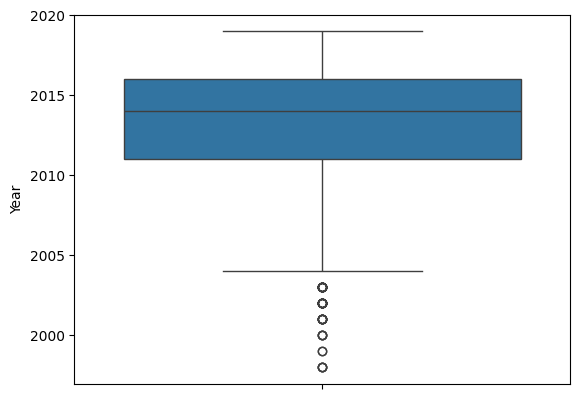

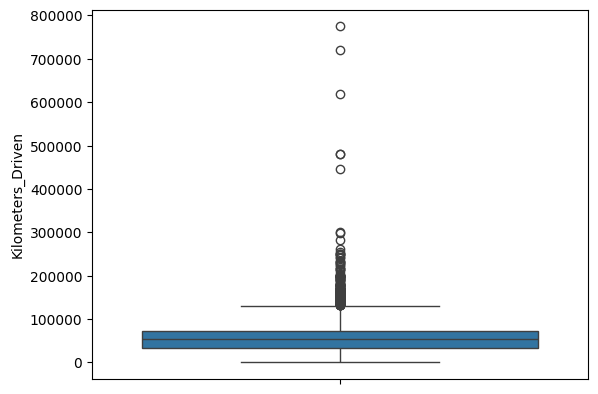

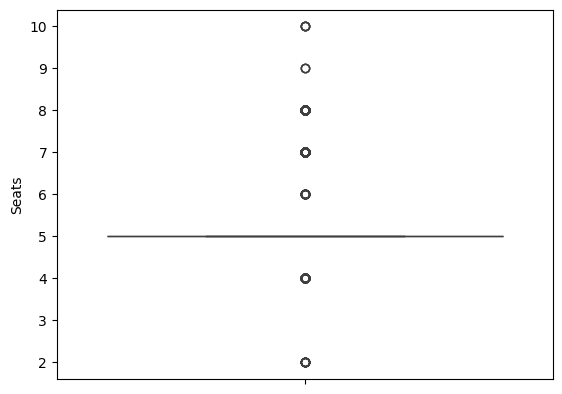

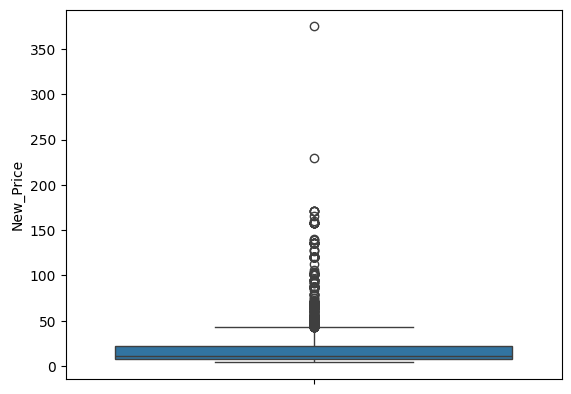

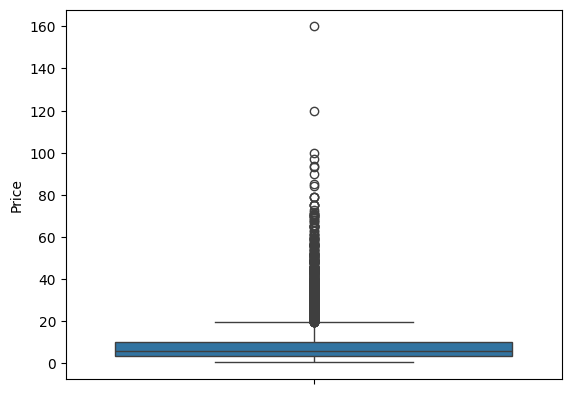

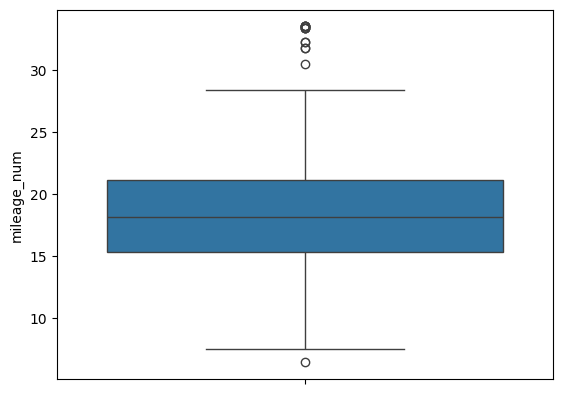

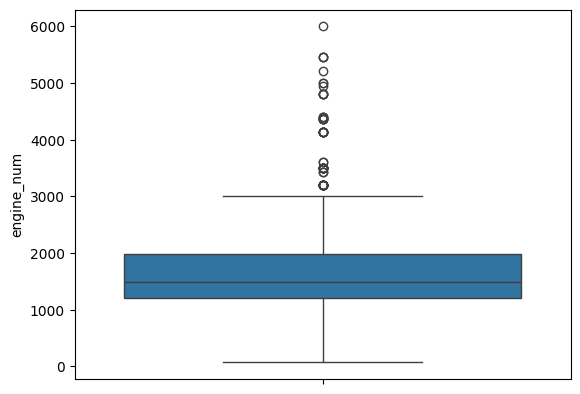

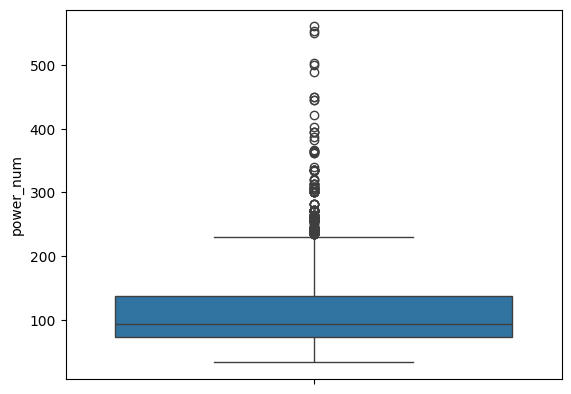

In [80]:
for i in s:
    sns.boxplot(df[i])
    plt.show()

In [81]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,0
Brand,0


In [82]:
df2=df.copy()

<Axes: xlabel='Price', ylabel='Count'>

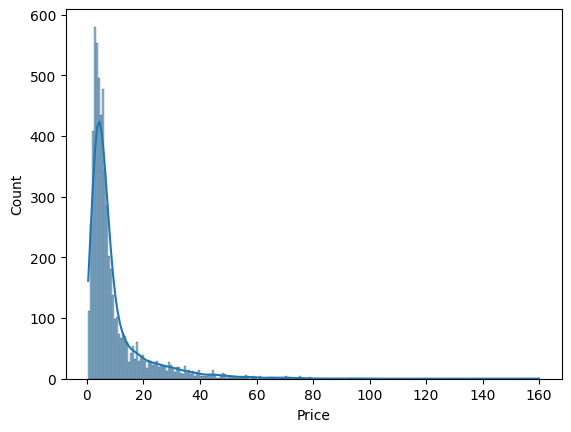

In [83]:
sns.histplot(df['Price'],kde=True)

In [84]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,0
Brand,0


In [85]:
df.describe()

,Year,Kilometers_Driven,Seats,New_Price,Price,mileage_num,engine_num,power_num
count,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,2013.358199,57668.767403,5.277953,21.499855,9.479468,18.311786,1620.220967,112.665697
std,3.269742,37875.677079,0.803778,24.332922,11.187917,4.166036,600.503886,53.805356
min,1998.000000,171.000000,2.000000,3.910000,0.440000,6.400000,72.000000,34.200000
25%,2011.000000,34000.000000,5.000000,7.880000,3.500000,15.290000,1198.000000,74.000000
50%,2014.000000,53000.000000,5.000000,11.300000,5.640000,18.160000,1493.000000,93.700000
75%,2016.000000,73000.000000,5.000000,21.770000,9.950000,21.100000,1984.000000,138.100000
max,2019.000000,775000.000000,10.000000,375.000000,160.000000,33.540000,5998.000000,560.000000


In [86]:
df.select_dtypes(include=['object']).nunique()

,0
Location,11
Fuel_Type,5
Transmission,2
Owner_Type,4
Brand,31
Model,212


In [87]:
df['Transmission']=df['Transmission'].map({'Manual':0,'Automatic':1})

In [88]:
df['Transmission'].value_counts()

,count
Transmission,
0,4299
1,1720


In [89]:
df.select_dtypes(include=['object']).nunique()

,0
Location,11
Fuel_Type,5
Owner_Type,4
Brand,31
Model,212


In [90]:
df.groupby(['Fuel_Type'],as_index=False)['Price'].mean().sort_values(by='Price',ascending=False)

,Fuel_Type,Price
2,Electric,12.875000
1,Diesel,12.840605
4,Petrol,5.701100
0,CNG,3.516786
3,LPG,2.487000


In [91]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Diesel,3205
Petrol,2746
CNG,56
LPG,10
Electric,2


In [92]:
df.groupby(['Transmission'])['Price'].mean()

,Price
Transmission,
0,5.332703
1,19.843971


In [93]:
df.groupby(['Location'])['Price'].mean().sort_values(ascending=False)

,Price
Location,
Coimbatore,15.078223
Bangalore,13.328631
Kochi,11.179186
Hyderabad,9.776550
Delhi,9.707726
Mumbai,9.429329
Ahmedabad,8.457321
Chennai,7.753623
Pune,6.726254


In [94]:
df.groupby(['Brand','Model'],as_index=False)['Price'].mean().sort_values(by='Price',ascending=False).head(20)

,Brand,Model,Price
86,Lamborghini,Gallardo,120.000000
81,Jaguar,F,100.000000
145,Mercedes-Benz,SLC,68.980000
138,Mercedes-Benz,GLS,67.500000
146,Mercedes-Benz,SLK-Class,66.846667
161,Porsche,Boxster,64.000000
84,Jaguar,XJ,63.898333
137,Mercedes-Benz,GLE,60.444167
164,Porsche,Panamera,59.110000
21,Bentley,Continental,59.000000


In [95]:
df.groupby(['Owner_Type'])['Price'].mean().sort_values(ascending=False)

,Price
Owner_Type,
First,9.962445
Second,7.599886
Third,5.007257
Fourth & Above,3.280000


<Axes: >

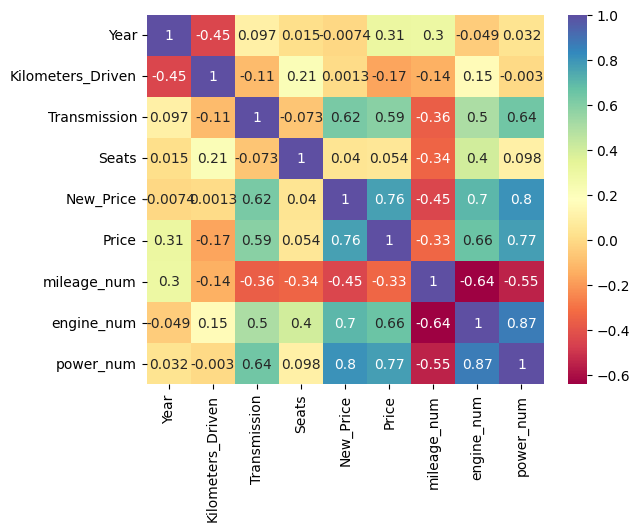

In [96]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True,cmap='Spectral')

In [97]:
df.shape

(6019, 14)

In [98]:
df.dtypes

,0
Location,object
Year,int64
Kilometers_Driven,float64
Fuel_Type,object
Transmission,int64
Owner_Type,object
Seats,float64
New_Price,float64
Price,float64
Brand,object


In [99]:
df.shape

(6019, 14)

In [100]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
Year,22
Kilometers_Driven,3092
Transmission,2
Seats,8
New_Price,563
Price,1373
mileage_num,429
engine_num,146
power_num,372


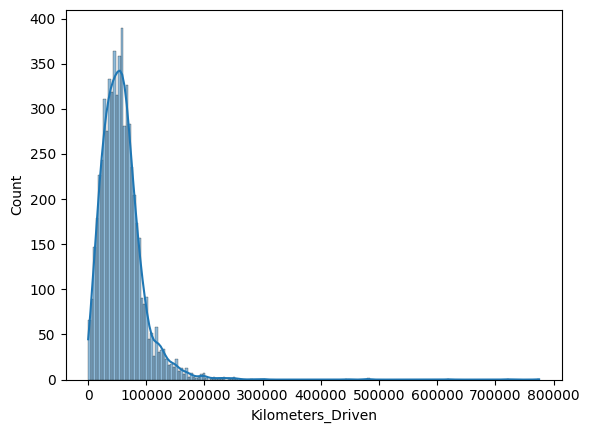

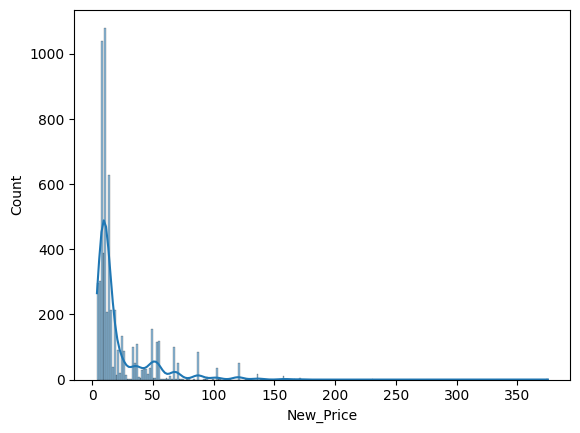

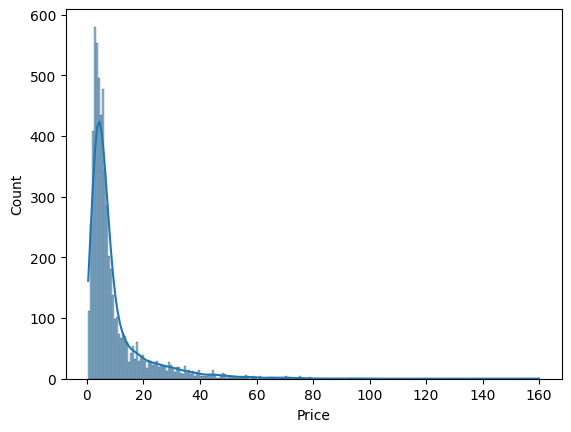

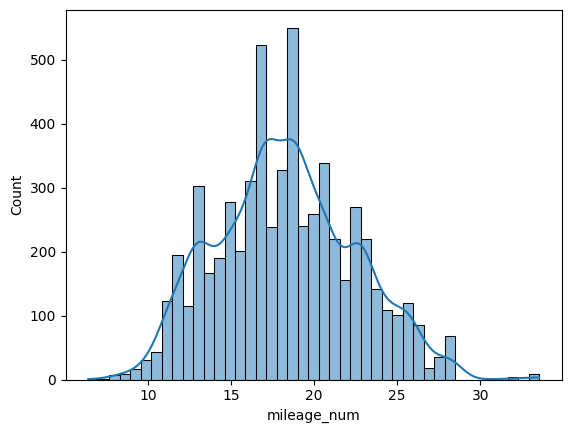

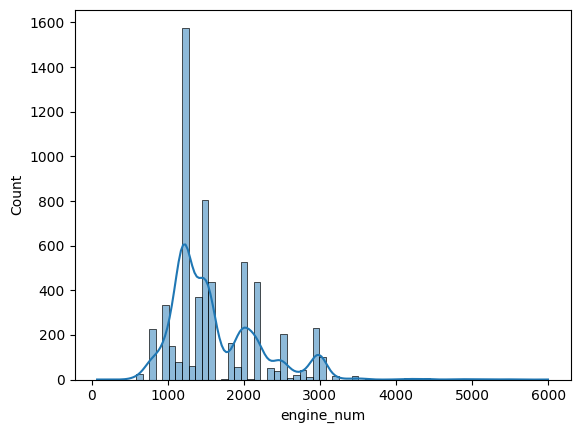

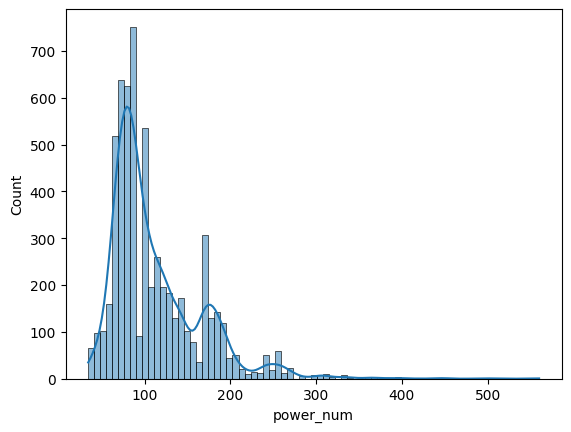

In [101]:
# isme check kr rhe h ki konse continous column ka uniform distribution nahi h, usko np.log krenge
# Features jinka range bahut wide hai
w=['Kilometers_Driven','New_Price','Price','mileage_num','engine_num','power_num']

for i in w:
    sns.histplot(df[i],kde=True)
    plt.show()

In [102]:
# kilometers driven
# new price
# price
# engine_num
# power_num

In [103]:
df['kilometers_driven_log']=np.log(df['Kilometers_Driven'])
df['new_price_log']=np.log(df['New_Price'])
df['price_log']=np.log(df['Price'])
df['engine_num_log']=np.log(df['engine_num'])
df['power_num_log']=np.log(df['power_num'])

In [104]:
for col in ['kilometers_driven_log', 'new_price_log', 'price_log', 'engine_num_log', 'power_num_log']:
    print(f"{col} max value: {df[col].max()}")

kilometers_driven_log max value: 13.560618308335483
new_price_log max value: 5.926926025970411
price_log max value: 5.075173815233827
engine_num_log max value: 8.699181359308954
power_num_log max value: 6.327936783729195


In [105]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
New_Price,0
Price,0
Brand,0


In [106]:
df.describe()

,Year,Kilometers_Driven,Transmission,Seats,New_Price,Price,mileage_num,engine_num,power_num,kilometers_driven_log,new_price_log,price_log,engine_num_log,power_num_log
count,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,2013.358199,57668.767403,0.285762,5.277953,21.499855,9.479468,18.311786,1620.220967,112.665697,10.758007,2.683628,1.825095,7.330326,4.631919
std,3.269742,37875.677079,0.451814,0.803778,24.332922,11.187917,4.166036,600.503886,53.805356,0.712971,0.797382,0.874059,0.339908,0.416897
min,1998.000000,171.000000,0.000000,2.000000,3.910000,0.440000,6.400000,72.000000,34.200000,5.141664,1.363537,-0.820981,4.276666,3.532226
25%,2011.000000,34000.000000,0.000000,5.000000,7.880000,3.500000,15.290000,1198.000000,74.000000,10.434116,2.064328,1.252763,7.088409,4.304065
50%,2014.000000,53000.000000,0.000000,5.000000,11.300000,5.640000,18.160000,1493.000000,93.700000,10.878047,2.424803,1.729884,7.308543,4.540098
75%,2016.000000,73000.000000,1.000000,5.000000,21.770000,9.950000,21.100000,1984.000000,138.100000,11.198215,3.080533,2.297573,7.592870,4.927978
max,2019.000000,775000.000000,1.000000,10.000000,375.000000,160.000000,33.540000,5998.000000,560.000000,13.560618,5.926926,5.075174,8.699181,6.327937


In [107]:
# kilometers driven
# new price
# price
# engine_num
# power_num

In [108]:
df.drop(['Kilometers_Driven','New_Price','engine_num','power_num'],axis=1,inplace=True)

In [109]:
df.dtypes

,0
Location,object
Year,int64
Fuel_Type,object
Transmission,int64
Owner_Type,object
Seats,float64
Price,float64
Brand,object
Model,object
mileage_num,float64


In [110]:
df.describe()

,Year,Transmission,Seats,Price,mileage_num,kilometers_driven_log,new_price_log,price_log,engine_num_log,power_num_log
count,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,2013.358199,0.285762,5.277953,9.479468,18.311786,10.758007,2.683628,1.825095,7.330326,4.631919
std,3.269742,0.451814,0.803778,11.187917,4.166036,0.712971,0.797382,0.874059,0.339908,0.416897
min,1998.000000,0.000000,2.000000,0.440000,6.400000,5.141664,1.363537,-0.820981,4.276666,3.532226
25%,2011.000000,0.000000,5.000000,3.500000,15.290000,10.434116,2.064328,1.252763,7.088409,4.304065
50%,2014.000000,0.000000,5.000000,5.640000,18.160000,10.878047,2.424803,1.729884,7.308543,4.540098
75%,2016.000000,1.000000,5.000000,9.950000,21.100000,11.198215,3.080533,2.297573,7.592870,4.927978
max,2019.000000,1.000000,10.000000,160.000000,33.540000,13.560618,5.926926,5.075174,8.699181,6.327937


In [111]:
X=df.drop(['Price','price_log'],axis=1)
y=df['Price']

In [112]:
df.nunique()

,0
Location,11
Year,22
Fuel_Type,5
Transmission,2
Owner_Type,4
Seats,8
Price,1373
Brand,31
Model,212
mileage_num,429


In [113]:
X.shape

(6019, 13)

In [114]:
X.columns.tolist()

['Location',
 'Year',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Seats',
 'Brand',
 'Model',
 'mileage_num',
 'kilometers_driven_log',
 'new_price_log',
 'engine_num_log',
 'power_num_log']

In [115]:
X=pd.get_dummies(X,columns=df.select_dtypes(include=['object']).columns.tolist(),drop_first=True)

In [116]:
sc=StandardScaler()
X_Scaled=sc.fit_transform(X)

In [117]:
X.columns

Index(['Year', 'Transmission', 'Seats', 'mileage_num', 'kilometers_driven_log',
       'new_price_log', 'engine_num_log', 'power_num_log',
       'Location_Bangalore', 'Location_Chennai',
       ...
       'Model_Xcent', 'Model_Xenon', 'Model_Xylo', 'Model_Yeti', 'Model_Z4',
       'Model_Zen', 'Model_Zest', 'Model_i10', 'Model_i20', 'Model_redi-GO'],
      dtype='object', length=266)

In [118]:
X_train,X_test,y_train,y_test=train_test_split(X_Scaled,y,test_size=0.2,random_state=1)

In [119]:
X_train.shape

(4815, 266)

In [120]:
X_test.shape

(1204, 266)

In [121]:
y_test.shape

(1204,)

In [122]:
y_train.shape

(4815,)

In [123]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [124]:
y_pred_train=lr.predict(X_train)
y_pred_test=lr.predict(X_test)

In [125]:
r2_score(y_test,y_pred_test)

0.8252522250653844

In [126]:
r2_score(y_train,y_pred_train)

0.8544507385946197

In [127]:
mean_absolute_percentage_error(y_test,y_pred_test)

0.40548841771052013

In [128]:
mean_absolute_percentage_error(y_train,y_pred_train)

0.446661046386541

In [129]:
X = df.drop(["Price", "price_log"], axis=1)
y = df[["price_log"]]

X = pd.get_dummies(X,columns=X.select_dtypes(include=["object"]).columns.tolist(),drop_first=True)

# sc=StandardScaler()
# X_Scaled=sc.fit_transform(X)

In [130]:
X_train2, X_test2, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [131]:
X_train.shape

(4815, 266)

In [132]:
X_test.shape

(1204, 266)

In [133]:
y_test.shape

(1204, 1)

In [134]:
y_train.shape

(4815, 1)

In [135]:
lr2=LinearRegression()
lr2.fit(X_train2,y_train)

LinearRegression()

In [136]:
y_pred_train2=lr2.predict(X_train2)
y_pred_test2=lr2.predict(X_test2)

In [137]:
y_actual_train=np.exp(y_pred_train2)
y_actual_test=np.exp(y_pred_test2)

In [138]:
r2_score(y_test,y_actual_test)

-220.31632069211838

In [139]:
r2_score(y_train,y_actual_train)

-191.0750519649025

In [140]:
mean_absolute_percentage_error(y_test,y_actual_test)

12873559770191.592

In [141]:
mean_absolute_percentage_error(y_train,y_actual_train)

13537371115257.521